In [1]:
import matplotlib.pyplot as plt
from glob import glob
import numpy as np
from matplotlib.gridspec import GridSpec
import cmocean.cm as cm
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cft
import scipy.io as sio
from tqdm import tqdm
import seawater as sw
import matplotlib.ticker as mticker
import matplotlib.patheffects as mpe

In [2]:
# Set figures properties
import seaborn as sns
sns.set_style('darkgrid')
# sns.reset_orig()
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

In [3]:
def mod_grad(Ln, Lt, field):
    ''' Compute the module of a gradient in F(x,y)
    ===========================================================================
    Input :
    -> LON: [m,n]
    -> LAT: [m,n]
    -> field: [m,n]
    ===========================================================================
    Output:
    -> |$\nabla( F[x,y] )$|
    ===========================================================================
    Felipe Vilela da Silva @ IMAS, UTas, AU
    27-11-2020
    '''
    # LON, LAT = np.meshgrid(Ln, Lt)
    
    [trash,dlonx]  = np.gradient(LON)
    dx = dlonx*np.cos(LAT*np.pi/180)*111195.
    [dlaty,trash] = np.gradient(LAT)
    dy = dlaty*111195.

    [dfy,dfx] = np.gradient(field)
    dfdx, dfdy = dfx/dx, dfy/dy
    
    _f_ = np.sqrt((dfdx)**2 + (dfdy)**2)
    
    return _f_

In [4]:
def argnear(dat,val,how_many=1):
    dif = np.abs(dat-val)
    idx = np.argsort(dif)
    return idx[:how_many]

In [5]:
import cosima_cookbook as cc
# Importing the ocean depth on t-cells in the chosen time period and domain
session = cc.database.create_session()
expt01 = '01deg_jra55v140_iaf'  # 01-deg and daily experiment 
bathy = cc.querying.getvar(expt01, 'ht', session, n=1)

In [6]:
path = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/data/'
data_meander   = glob(path + 'altimetry_meander_location_daily_1993_2019_3m_30thrs.mat')
# data_bathy      = glob(path + 'GMRTv3_7_20200805topo_standing_meander.grd')
lon_boundaries = glob(path + 'meander_regions_lat_lon.mat')

meander_var = sio.loadmat(data_meander[0])
upstream_lon, downstream_lon = sio.loadmat(lon_boundaries[0])['upstream_lon'][0,0], sio.loadmat(lon_boundaries[0])['downstream_lon'][0,0]

## Some information about the .mat files
--> meand_lat and meand_lon are the grid; --> meand_loc represent the pathway of the meander

--> meand_N_lat and meand_S_lat show the width of the meander's peak based on the gradient of how often (probability) the front is there

--> relat_thresh shows the threshold of prabability of occurance of finding the location of the meander

Amelie's file contain monthly information for the period from Jan  1993 to May 2019.

In [7]:
time      = meander_var['meand_time'][0]
lon, lat  = meander_var['meand_lon'][:,0], meander_var['meand_lat'][0]
LON, LAT  = np.meshgrid(lon, lat)
lat_front = meander_var['meand_loc_lat'].T
ADT_altim = meander_var['meand_alti_ADT'].T

In [8]:
arg_true  = np.argwhere(np.isnan(lat_front[1]) == False)[0,0]
lat_meand = lat_front[:, arg_true:]
lon_meand = lon[arg_true:]

In [9]:
from datetime import datetime
from datetime import timedelta
# import pandas as pd

time_diff = np.cumsum(np.append(0, time[1:]-time[:-1]))
dates = np.array([])
for t in range(len(time)):
    dates = np.append(dates, datetime(1993,1,15) + timedelta(days=int(time_diff[t])))

In [10]:
window = 4

len_front_chunk = np.random.rand(len(time), len(lon_meand) - window*2)*np.nan
for t in range(len(time)):
    for k in range(window, len(lon_meand) - window):
        len_front_chunk[t, k-window] = np.sum(sw.dist(lat_meand[t, k-window:k+window+1], 
                                                     lon_meand[k-window:k+window+1])[0])

In [11]:
######################### Computing the meander length and ADT gradient ##############################
_adt_        = np.array([mod_grad(LON, LAT, ADT_altim[t]) for t in range(len(time))])
#################### BUILDING AN XARRAY AND COMPUTING TIME-ROLLING AVERAGE ##############################
_ADT_ = xr.DataArray(_adt_, dims=('time','lat','lon'), coords = dict(lon = lon, lat = lat, time =dates))
wdw = 3
_ADT_wdw = _ADT_.rolling(time = wdw, center = True).mean('time').compute()

### Let's apply some smoothing along the coordinates

In [12]:
from scipy.ndimage.filters import gaussian_filter
sig = 1
lon_meand_filt = gaussian_filter(lon_meand, sigma = sig)
lat_meand_filt = np.array([gaussian_filter(lat_meand[t], sigma = sig) for t in range(len(time))])
###########################################################################################
len_front_chunk_filt = np.random.rand(len(time), len(lon_meand) - window*2)*np.nan
for t in range(len(time)):
    for k in range(window, len(lon_meand) - window):
        len_front_chunk_filt[t, k-window] = np.sum(sw.dist(lat_meand_filt[t, k-window:k+window], 
                                                           lon_meand_filt[k-window:k+window])[0])

In [13]:
_ADT_mean     = _ADT_.mean('time')
_ADT_wdw_mean = _ADT_wdw.mean('time')
lat_meand_mean = np.nanmean(lat_meand, axis = 0)
lat_filt_mean  = np.nanmean(lat_meand_filt, axis = 0)

## Now, let's compute the trends

In [14]:
from sklearn import linear_model
def lin_reg(variable):
    linear_reg = linear_model.LinearRegression()
    y_true  = variable[~np.isnan(variable)]
    x_true  = np.arange(len(y_true))
    X_input = x_true.reshape(len(x_true),1)
    Y_input = y_true.reshape(len(x_true),1)

    linear_reg.fit(X_input, Y_input)
    y_pred   = linear_reg.predict(X_input)
    reg_coef = linear_reg.coef_[0,0]

    return y_pred.ravel(), reg_coef

In [15]:
from scipy import stats
slope = np.random.rand(len(lon_meand) - window*2)*np.nan
p_value, slope_smth, p_value_smth = slope.copy(), slope.copy(), slope.copy()
X = np.arange(len(len_front_chunk[1:-1]))
for k in range(len_front_chunk.shape[1]):
    results = stats.linregress(X, len_front_chunk[1:-1, k])
    results_smth = stats.linregress(X, len_front_chunk_filt[1:-1, k])
    ############################################################
    slope[k], p_value[k] = results.slope, results.pvalue
    slope_smth[k], p_value_smth[k] = results_smth.slope, results_smth.pvalue
    
# variance, smth_variance = np.nanvar(len_front_chunk), np.nanvar(len_front_chunk_filt)

In [29]:
cond_pvalue = p_value < 0.05
slope_true  = slope[cond_pvalue]

cond_pvalue_smth = p_value_smth < 0.05
slope_true_smth  = slope_smth[cond_pvalue_smth]

## Figures

In [55]:
path_fig_raw    = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/scripts/figures/animations/raw_meander_pos/'
path_fig_smooth = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/scripts/figures/animations/smooth_meander_pos/'
props = dict(boxstyle='round', facecolor='w')
grd = GridSpec(100,100)
outline = mpe.withStroke(linewidth=3, foreground='k')
outline_w = mpe.withStroke(linewidth=3, foreground='w')

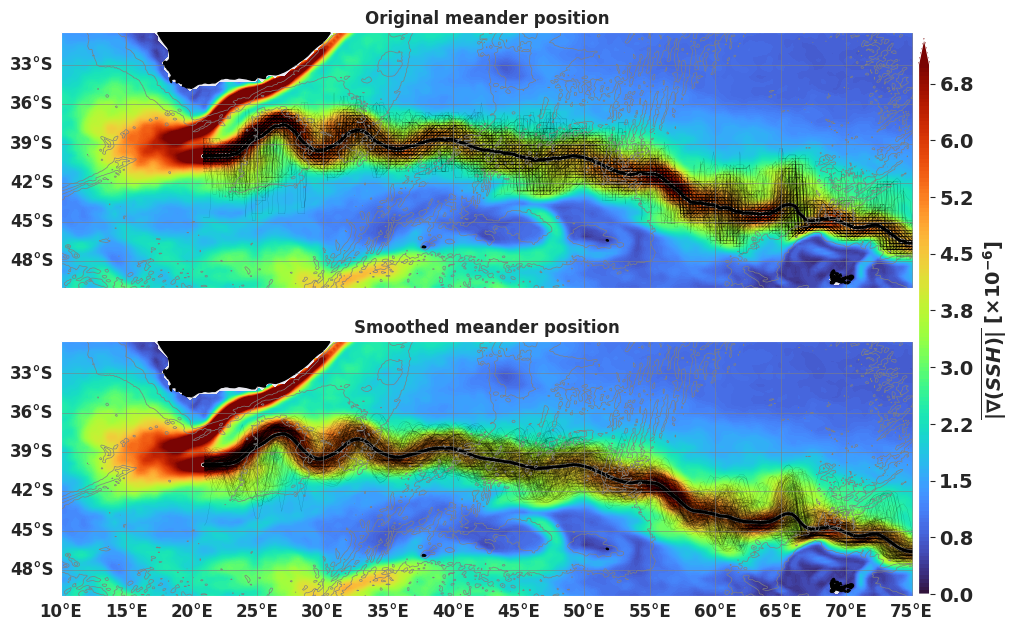

In [17]:
fig = plt.figure(figsize = (11,8))
grd = GridSpec(100,100)
extent = [9.99, 75.1, -50, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)

####################### FIGURE 1
ax = [fig.add_subplot(grd[:50,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[50:,:], projection=ccrs.PlateCarree())]

cf1 = ax[0].contourf(lon, lat, _ADT_mean*1e6, np.arange(0,7.05,.05), cmap='turbo', extend='max')   
ax[0].plot(lon_meand, lat_meand_mean, color = 'k', path_effects=[outline_w], linewidth = 2)

cf1 = ax[1].contourf(lon, lat, _ADT_wdw_mean*1e6, np.arange(0,7.05,.05), cmap='turbo', extend='max')   
ax[1].plot(lon_meand, lat_filt_mean, color = 'k', path_effects=[outline_w], linewidth = 2)

for t in range(len(dates)):
    ax[0].plot(lon_meand, lat_meand[t], color = 'k', linewidth = .1, alpha=.5)
    ax[1].plot(lon_meand_filt, lat_meand_filt[t], color = 'k', linewidth = .1, alpha=.5)

####################################### Details
for i in range(len(ax)):
    ax[i].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='grey', 
                  linewidths=.5, transform=ccrs.PlateCarree())
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    if i > 0 :
        gl.bottom_labels = True
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
    gl.ylabel_style = {'size': 12}
    gl.xlabel_style = {'size': 12}

ax[0].set_title('Original meander position', fontsize = 12)
ax[1].set_title('Smoothed meander position', fontsize = 12)
# ax[1].legend(loc = 'lower left', fontsize = 10, facecolor = 'lightgrey', shadow=True)

## Colorbar
bar = plt.axes([0.905, 0.145, 0.01, 0.695])
cbar = plt.colorbar(cf1, cax = bar, format = '%.1f')  
cbar.set_label(r'$\overline{|\nabla(SSH)|}$ [$\times 10^{-6}$]') 

Text(0.5, 1.0, 'The chunk is based on a $\\pm1\\degree$ window along the front')

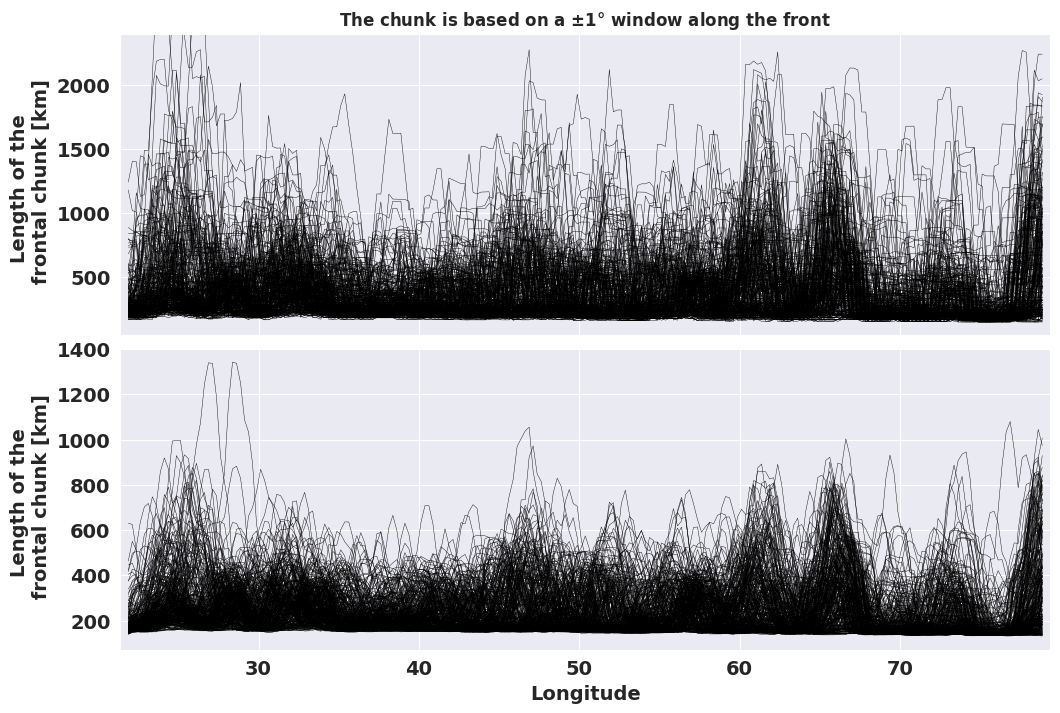

In [60]:
fig = plt.figure(figsize = (12,8))
grd = GridSpec(100,100)
ax = [fig.add_subplot(grd[:49,:]), fig.add_subplot(grd[51:,:])]

[ax[0].plot(lon_meand[window:-window], len_front_chunk[t], color = 'k', linewidth = .3) for t in range(len(time))]
[ax[1].plot(lon_meand[window:-window], len_front_chunk_filt[t], color = 'k', linewidth = .3) for t in range(len(time))]
pass

for i in range(len(ax)):
    ax[i].set_ylabel('Length of the \n frontal chunk [km]')
    ax[i].set_xlim(lon_meand[2:-2][0], lon_meand[2:-2][-1])
ax[0].set_xticklabels([])
ax[0].set_ylim(50,700)
ax[0].set_ylim(50,2400)
ax[1].set_xlabel('Longitude')
ax[0].annotate(text = 'Original meander position', xy =(dates[3], 5450), xycoords = 'data', bbox=props, zorder =200, fontsize = 11)
ax[1].annotate(text = 'Smoothed meander position', xy =(dates[3], 2270), xycoords = 'data', bbox=props, zorder =200, fontsize = 11)
ax[0].set_title('The chunk is based on a $\pm1\degree$ window along the front', fontsize = 12)


Text(0.5, 1.0, 'Statistics using the original frontal position in a $\\pm1\\degree$ window')

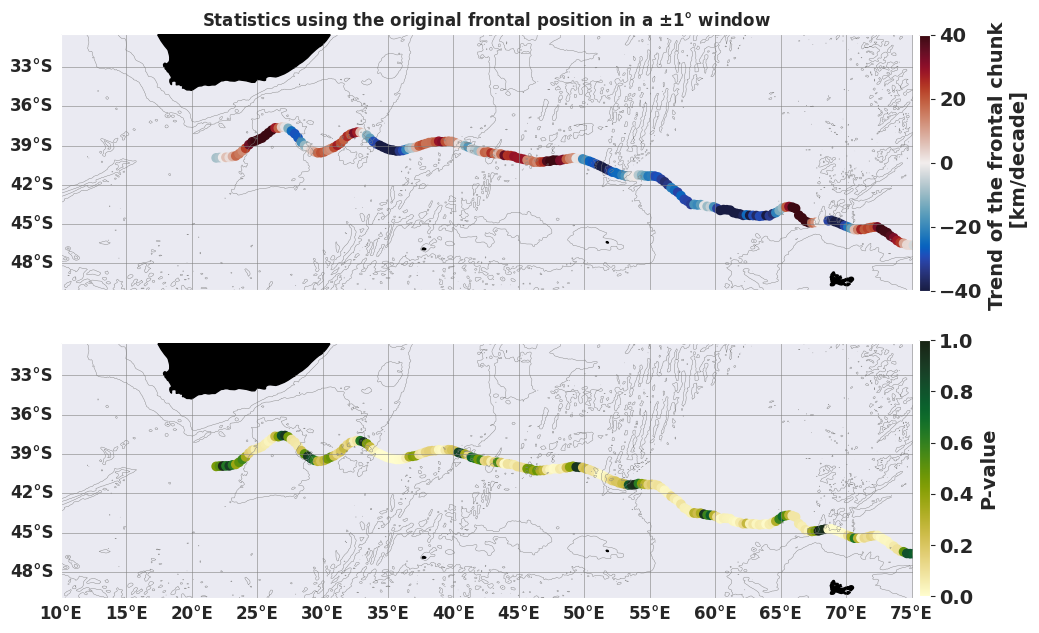

In [61]:
fig = plt.figure(figsize = (11,8))
grd = GridSpec(100,100)
extent = [9.99, 75.1, -50, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)

####################### FIGURE 1
ax = [fig.add_subplot(grd[:50,:], projection=ccrs.PlateCarree()), fig.add_subplot(grd[50:,:], projection=ccrs.PlateCarree())]

cf1 = ax[0].scatter(lon_meand[window:-window], lat_meand_mean[window:-window], c = slope*12*10, cmap = cm.balance, vmin = -40, vmax = 40)   
cf2 = ax[1].scatter(lon_meand[window:-window], lat_meand_mean[window:-window], c = p_value, cmap = cm.speed, vmin = 0, vmax = 1)   

####################################### Details
for i in range(len(ax)):
    ax[i].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='grey', 
                  linewidths=.3, transform=ccrs.PlateCarree())
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    if i > 0 :
        gl.bottom_labels = True
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
    gl.ylabel_style = {'size': 12}
    gl.xlabel_style = {'size': 12}

## Colorbar
bar = plt.axes([0.905, 0.527, 0.01, 0.32])
cbar = plt.colorbar(cf1, cax = bar)  
cbar.set_label('Trend of the frontal chunk \n [km/decade]') 

bar = plt.axes([0.905, 0.145, 0.01, 0.32])
cbar = plt.colorbar(cf2, cax = bar)  
cbar.set_label('P-value') 
ax[0].set_title('Statistics using the original frontal position in a $\pm1\degree$ window', fontsize = 12)

Text(0.5, 1.0, 'Statistics using the smoothed frontal position in a $\\pm1\\degree$ window')

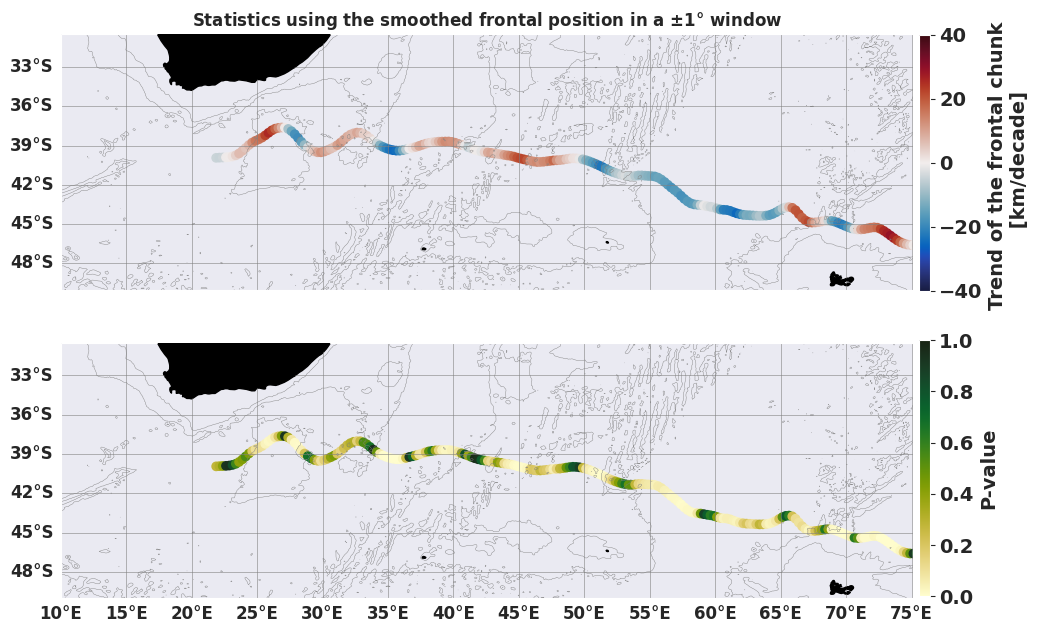

In [65]:
fig = plt.figure(figsize = (11,8))
grd = GridSpec(100,100)
extent = [9.99, 75.1, -50, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)

####################### FIGURE 1
ax = [fig.add_subplot(grd[:50,:], projection=ccrs.PlateCarree()), fig.add_subplot(grd[50:,:], projection=ccrs.PlateCarree())]

cf1 = ax[0].scatter(lon_meand[window:-window], lat_filt_mean[window:-window], c = slope_smth*12*10, cmap = cm.balance, vmin = -40, vmax = 40)   
cf2 = ax[1].scatter(lon_meand[window:-window], lat_filt_mean[window:-window], c = p_value_smth, cmap = cm.speed, vmin = 0, vmax = 1)   

####################################### Details
for i in range(len(ax)):
    ax[i].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='grey', 
                  linewidths=.3, transform=ccrs.PlateCarree())
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    if i > 0 :
        gl.bottom_labels = True
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
    gl.ylabel_style = {'size': 12}
    gl.xlabel_style = {'size': 12}

## Colorbar
bar = plt.axes([0.905, 0.527, 0.01, 0.32])
cbar = plt.colorbar(cf1, cax = bar)  
cbar.set_label('Trend of the frontal chunk \n [km/decade]') 

bar = plt.axes([0.905, 0.145, 0.01, 0.32])
cbar = plt.colorbar(cf2, cax = bar)  
cbar.set_label('P-value') 
ax[0].set_title('Statistics using the smoothed frontal position in a $\pm1\degree$ window', fontsize = 12)

## Only values where p_value < 0.05

Text(0.5, 1.0, 'Statistics using the original frontal position in a $\\pm1\\degree$ window')

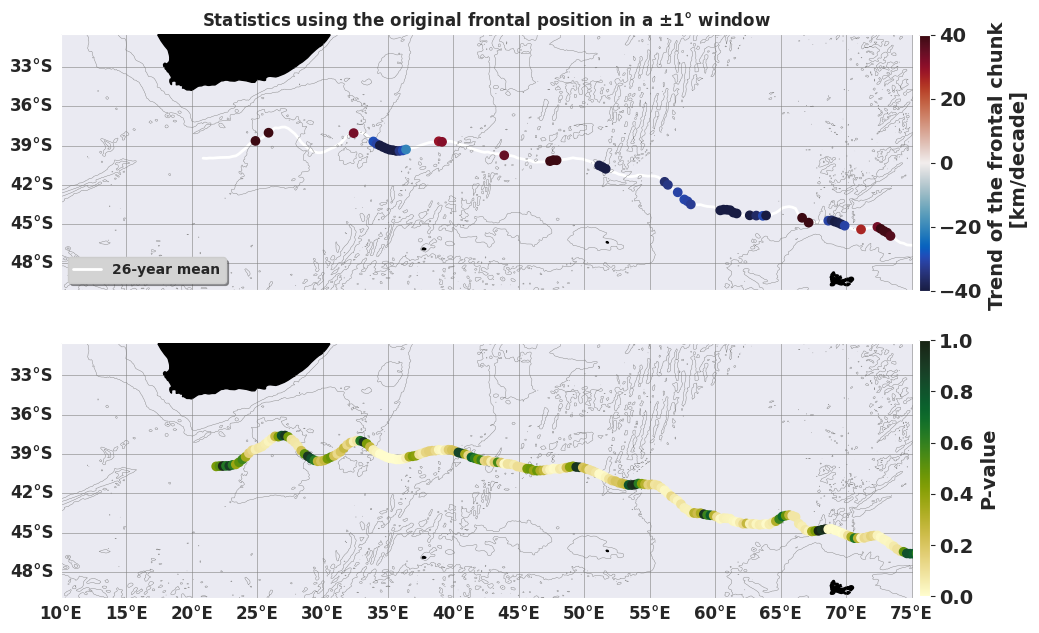

In [34]:
fig = plt.figure(figsize = (11,8))
grd = GridSpec(100,100)
extent = [9.99, 75.1, -50, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)

####################### FIGURE 1
ax = [fig.add_subplot(grd[:50,:], projection=ccrs.PlateCarree()), fig.add_subplot(grd[50:,:], projection=ccrs.PlateCarree())]

ax[0].plot(lon_meand, lat_meand_mean, color = 'w', linewidth = 2, label = '26-year mean')

cf1 = ax[0].scatter(lon_meand[window:-window][cond_pvalue], lat_meand_mean[window:-window][cond_pvalue], c = slope_true*12*10, cmap = cm.balance, vmin = -40, vmax = 40, zorder = 20)   
cf2 = ax[1].scatter(lon_meand[window:-window], lat_meand_mean[window:-window], c = p_value, cmap = cm.speed, vmin = 0, vmax = 1, zorder = 20)   

####################################### Details
ax[0].legend(loc = 'lower left', fontsize = 10, facecolor = 'lightgrey', shadow=True)
for i in range(len(ax)):
    ax[i].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='grey', 
                  linewidths=.3, transform=ccrs.PlateCarree())
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    if i > 0 :
        gl.bottom_labels = True
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
    gl.ylabel_style = {'size': 12}
    gl.xlabel_style = {'size': 12}

## Colorbar
bar = plt.axes([0.905, 0.527, 0.01, 0.32])
cbar = plt.colorbar(cf1, cax = bar)  
cbar.set_label('Trend of the frontal chunk \n [km/decade]') 

bar = plt.axes([0.905, 0.145, 0.01, 0.32])
cbar = plt.colorbar(cf2, cax = bar)  
cbar.set_label('P-value') 
ax[0].set_title('Statistics using the original frontal position in a $\pm1\degree$ window', fontsize = 12)

Text(0.5, 1.0, 'Statistics using the smoothed frontal position in a $\\pm1\\degree$ window')

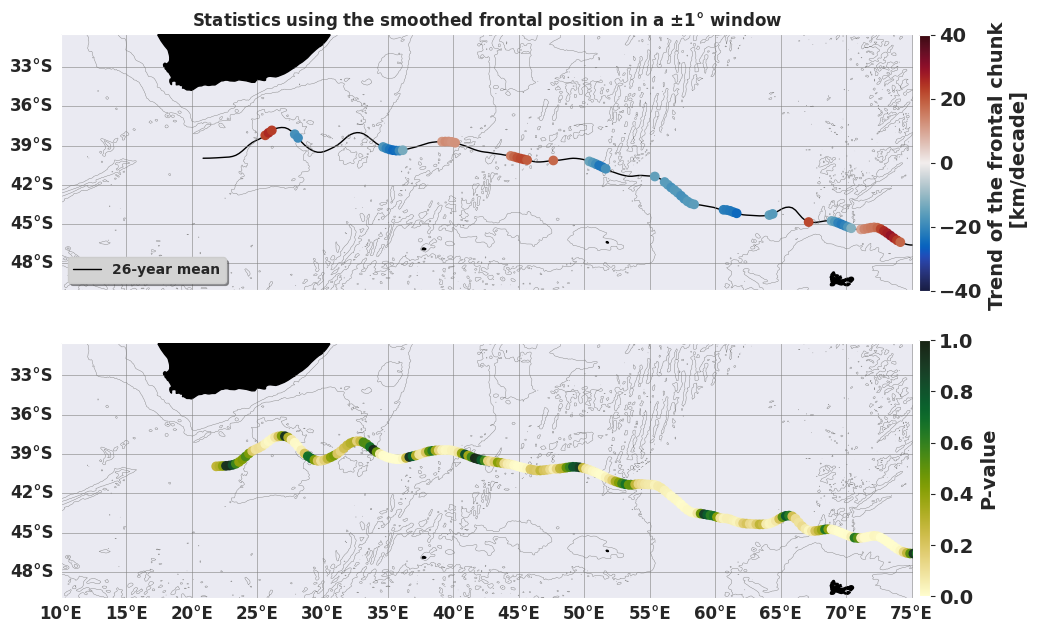

In [33]:
fig = plt.figure(figsize = (11,8))
grd = GridSpec(100,100)
extent = [9.99, 75.1, -50, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)

####################### FIGURE 1
ax = [fig.add_subplot(grd[:50,:], projection=ccrs.PlateCarree()), fig.add_subplot(grd[50:,:], projection=ccrs.PlateCarree())]

ax[0].plot(lon_meand, lat_filt_mean, color = 'k', linewidth = 1, label = '26-year mean')
cf1 = ax[0].scatter(lon_meand[window:-window][cond_pvalue_smth], lat_filt_mean[window:-window][cond_pvalue_smth], 
                    c = slope_true_smth*12*10, cmap = cm.balance, vmin = -40, vmax = 40, zorder = 20)   
cf2 = ax[1].scatter(lon_meand[window:-window], lat_filt_mean[window:-window], 
                    c = p_value_smth, cmap = cm.speed, vmin = 0, vmax = 1, zorder = 20)   

####################################### Details
ax[0].legend(loc = 'lower left', fontsize = 10, facecolor = 'lightgrey', shadow=True)
for i in range(len(ax)):
    ax[i].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='grey', 
                  linewidths=.3, transform=ccrs.PlateCarree())
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    if i > 0 :
        gl.bottom_labels = True
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
    gl.ylabel_style = {'size': 12}
    gl.xlabel_style = {'size': 12}

## Colorbar
bar = plt.axes([0.905, 0.527, 0.01, 0.32])
cbar = plt.colorbar(cf1, cax = bar)  
cbar.set_label('Trend of the frontal chunk \n [km/decade]') 

bar = plt.axes([0.905, 0.145, 0.01, 0.32])
cbar = plt.colorbar(cf2, cax = bar)  
cbar.set_label('P-value') 
ax[0].set_title('Statistics using the smoothed frontal position in a $\pm1\degree$ window', fontsize = 12)

## Different test changing the length of the window

Text(0.5, 1.0, 'Statistics using the original frontal position in a $\\pm0.25\\degree$ window')

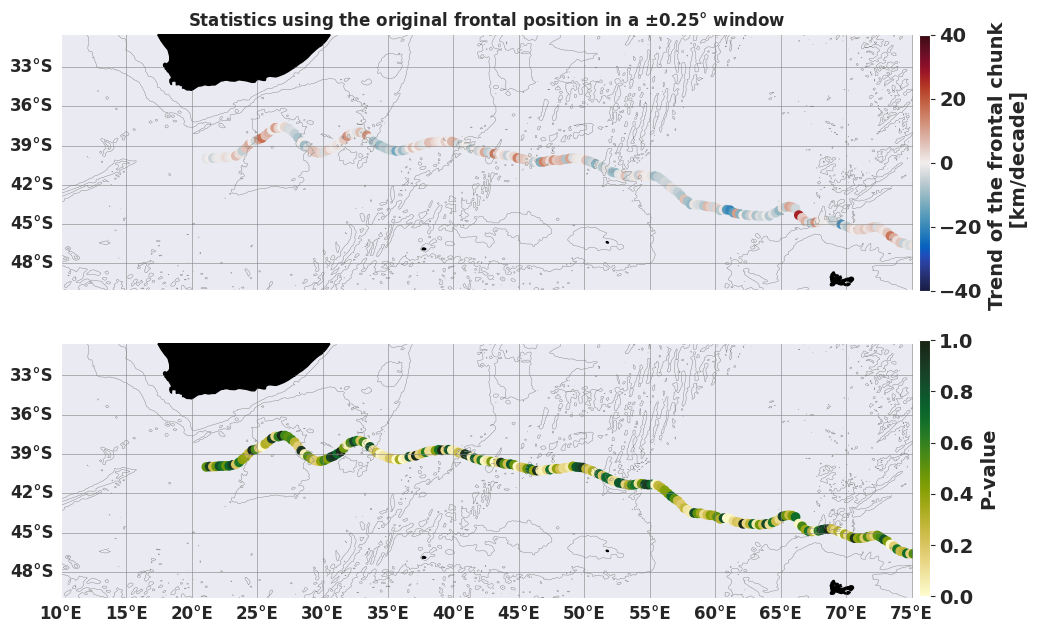

In [28]:
fig = plt.figure(figsize = (11,8))
grd = GridSpec(100,100)
extent = [9.99, 75.1, -50, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)

####################### FIGURE 1
ax = [fig.add_subplot(grd[:50,:], projection=ccrs.PlateCarree()), fig.add_subplot(grd[50:,:], projection=ccrs.PlateCarree())]

cf1 = ax[0].scatter(lon_meand[window:-window], lat_meand_mean[window:-window], c = slope*12*10, cmap = cm.balance, vmin = -40, vmax = 40)   
cf2 = ax[1].scatter(lon_meand[window:-window], lat_meand_mean[window:-window], c = p_value, cmap = cm.speed, vmin = 0, vmax = 1)   

####################################### Details
for i in range(len(ax)):
    ax[i].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='grey', 
                  linewidths=.3, transform=ccrs.PlateCarree())
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    if i > 0 :
        gl.bottom_labels = True
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
    gl.ylabel_style = {'size': 12}
    gl.xlabel_style = {'size': 12}

## Colorbar
bar = plt.axes([0.905, 0.527, 0.01, 0.32])
cbar = plt.colorbar(cf1, cax = bar)  
cbar.set_label('Trend of the frontal chunk \n [km/decade]') 

bar = plt.axes([0.905, 0.145, 0.01, 0.32])
cbar = plt.colorbar(cf2, cax = bar)  
cbar.set_label('P-value') 
ax[0].set_title('Statistics using the original frontal position in a $\pm0.25\degree$ window', fontsize = 12)